### Importación de librerías necesárias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
# pd.set_option('display.max_colwidth',1000)

### Importando el dataset

In [2]:
df_en = pd.read_csv('../Data/raw_data_en.csv')

In [3]:
df_en.head()

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


Target mapping 

0 = Fake news <br>
1 = Actual news

In [4]:
LABEL_NAMES = {0: "Fake", 1: "Actual"}

In [5]:
df_en.info()
df_en.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6000 non-null   object
 1   text     6000 non-null   object
 2   subject  6000 non-null   object
 3   date     6000 non-null   object
 4   label    6000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 234.5+ KB


title      5884
text       5830
subject       8
date       1911
label         2
dtype: int64

### Statistics and quality

In [6]:
summary = pd.DataFrame({
    "Statistic": [
        "Rows",
        "Columns",
        "Missing cells",
        "Fully duplicated rows",
        "Duplicate titles",
        "Duplicate article texts",
    ],
    "Value": [
        len(df_en),
        df_en.shape[1],
        int(df_en.isna().sum().sum()),
        int(df_en.duplicated().sum()),
        int(df_en.duplicated(subset=["title"]).sum()),
        int(df_en.duplicated(subset=["text"]).sum()),
    ],
})

display(summary)

print("\nMissing values by column:")
display(df_en.isna().sum().to_frame("missing_count"))

print("\nClass counts:")
class_summary = (
    df_en["label"]
    .value_counts()
    .sort_index()
    .rename(index=LABEL_NAMES)
    .to_frame("count")
)
class_summary["percent"] = (class_summary["count"] / len(df_en) * 100).round(2)
display(class_summary)

,Statistic,Value
0,Rows,6000
1,Columns,5
2,Missing cells,0
3,Fully duplicated rows,5
4,Duplicate titles,116
5,Duplicate article texts,170



Missing values by column:


,missing_count
title,0
text,0
subject,0
date,0
label,0



Class counts:


,count,percent
label,,
Fake,3000,50.0
Actual,3000,50.0


5 filas exactas duplicadas, <br>
116 títulos repetidos,<br>
170 textos repetidos.<br>

Eso equivale aproximadamente a:<br>

0,08% filas completamente duplicadas,<br>
1,93% títulos duplicados,<br>
2,83% textos duplicados.

### Check empty strings

In [7]:
text_cols = ["title", "text"]

for col in text_cols:
    empty_count = (
        df_en[col]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(col, empty_count)

title 0
text 66


In [8]:
empty_text = df_en["text"].astype(str).str.strip().eq("")

empty_text_by_label = pd.crosstab(
    df_en["label"],
    empty_text,
    normalize="index"
) * 100

empty_text_by_label.index = empty_text_by_label.index.map(LABEL_NAMES)

display(empty_text_by_label)

text,False,True
label,,
Fake,97.8,2.2
Actual,100.0,0.0


Los textos vacíos no están distribuidos aleatoriamente entre clases: los 66 casos pertenecen a Fake. Dado que el objetivo del clasificador será analizar contenido periodístico y estos registros carecen del cuerpo del artículo, su eliminación durante el preprocessing está justificada.

Excluyendo temporalmente los textos vacíos del cálculo para cuantificar los duplicados reales de contenido:

In [9]:
non_empty_text = df_en["text"].astype(str).str.strip().ne("")

duplicate_non_empty_texts = (
    df_en.loc[non_empty_text]
    .duplicated(subset=["text"])
    .sum()
)

print("Duplicated non-empty texts:", duplicate_non_empty_texts)

Duplicated non-empty texts: 106


El conteo inicial detecta 170 ocurrencias duplicadas en text. Sin embargo, 66 registros contienen un cuerpo vacío (""), por lo que una parte importante de esos duplicados corresponde simplemente a la repetición del valor vacío. Excluyendo los textos vacíos, quedan 106 ocurrencias duplicadas de artículos con contenido.

In [ ]:
duplicate_titles_after_text_dedup = (
    df_en
    .duplicated(subset=["title"])
    .sum()
)

print(
    "Duplicated titles after text dedup:",
    duplicate_titles_after_text_dedup
)

### Check duplicate titles

¿Un mismo título aparece en Real y Fake?

In [10]:
text_label_conflicts = (
    df_en.groupby("title")["label"]
    .nunique()
    .sort_values(ascending=False)
)

text_label_conflicts[text_label_conflicts > 1]

Series([], Name: label, dtype: int64)

### Check duplicate texts

¿Un mismo texto aparece en Real y Fake?

In [11]:
text_label_conflicts = (
    df_en.groupby("text")["label"]
    .nunique()
    .sort_values(ascending=False)
)

text_label_conflicts[text_label_conflicts > 1]

Series([], Name: label, dtype: int64)

No existen textos/títulos repetidos con labels diferentes.

No se detectan conflictos de label entre los títulos o textos repetidos. Algunos artículos duplicados aparecen asociados a distintos valores de subject, lo que refleja redundancia e inconsistencias en los metadatos temáticos. Los duplicados de contenido deberán tratarse antes del train/test split para evitar contaminación entre particiones.

In [12]:
df_en[
    df_en["title"].duplicated(keep=False)
].sort_values("title").head(20)

,title,text,subject,date,label
5091,$3.5 MILLION DOWN THE DRAIN….Day 5 WI Recount:...,Just think how many youth centers could have b...,left-news,"Dec 6, 2016",0
2449,$3.5 MILLION DOWN THE DRAIN….Day 5 WI Recount:...,Just think how many youth centers could have b...,politics,"Dec 6, 2016",0
1725,(VIDEO) UN CLIMATE CHANGE FREAKS: “We should m...,What an evil bunch of freaks! The agenda is so...,politics,"Apr 6, 2015",0
3457,(VIDEO) UN CLIMATE CHANGE FREAKS: “We should m...,What an evil bunch of freaks! The agenda is so...,left-news,"Apr 6, 2015",0
252,100% FED UP! WITH HILLARY 2016? WE’VE GOT THE ...,"Yada, yada, yada Hillary Clinton announced he...",politics,"Apr 13, 2015",0
5966,100% FED UP! WITH HILLARY 2016? WE’VE GOT THE ...,"Yada, yada, yada Hillary Clinton announced he...",left-news,"Apr 13, 2015",0
2279,5-Star Mooch and Free-Loading Granny Drop In F...,Nothing but the best for the queen and the que...,Government News,"Apr 20, 2015",0
491,5-Star Mooch and Free-Loading Granny Drop In F...,Nothing but the best for the queen and the que...,left-news,"Apr 20, 2015",0
2460,ABSOLUTE SUBMISSION: Trump Bows to Neocon Orth...,Consortium News Exclusive: In his Mideast trip...,Middle-east,"June 1, 2017",0
1943,ABSOLUTE SUBMISSION: Trump Bows to Neocon Orth...,Consortium News Exclusive: In his Mideast trip...,US_News,"June 1, 2017",0


Check Text + Title

In [13]:
tmp = df_en.dropna(subset=["title", "text"]).copy()

tmp["title_repeated_in_text"] = tmp.apply(
    lambda row:
        str(row["text"]).strip().lower().startswith(
            str(row["title"]).strip().lower()
        ),
    axis=1
)

result = pd.crosstab(
    tmp["label"],
    tmp["title_repeated_in_text"],
    normalize="index"
) * 100

result.index = result.index.map(LABEL_NAMES)

display(result.round(2))

title_repeated_in_text,False,True
label,,
Fake,99.97,0.03
Actual,100.00,0.00


Podemos usar text + title para el modelo, no estaremos duplicando la información. 

### Label Distribution

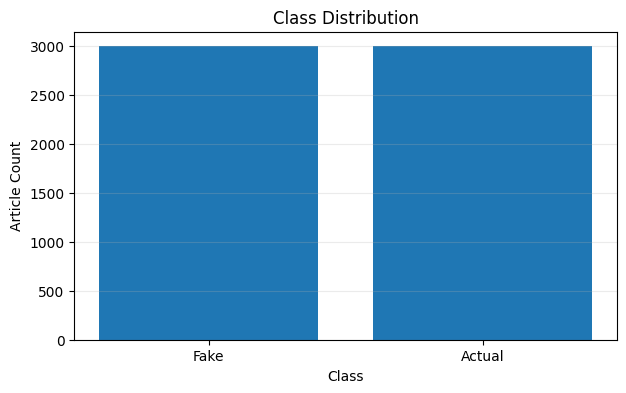

Imbalance ratio: 1.00
Decision: El conjunto de datos está perfectamente equilibrado entre noticias falsas y reales. Por lo tanto, no se justifica ningún tratamiento de desequilibrio de clases basándose únicamente en la distribución del objetivo.


In [14]:
label_counts = df_en["label"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar([LABEL_NAMES[i] for i in label_counts.index], label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Article Count")
plt.grid(axis="y", alpha=0.25)
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Decision: El conjunto de datos está perfectamente equilibrado entre noticias falsas y reales. Por lo tanto, no se justifica ningún tratamiento de desequilibrio de clases basándose únicamente en la distribución del objetivo.")
else:
    print("Decision: Pesos a las clases o remuestreo necesários")

### Check feature Leakage

,Fake,Actual
subject,,
Government News,185,0
Middle-east,100,0
News,1175,0
US_News,97,0
left-news,573,0
politics,870,0
politicsNews,0,1564
worldnews,0,1436


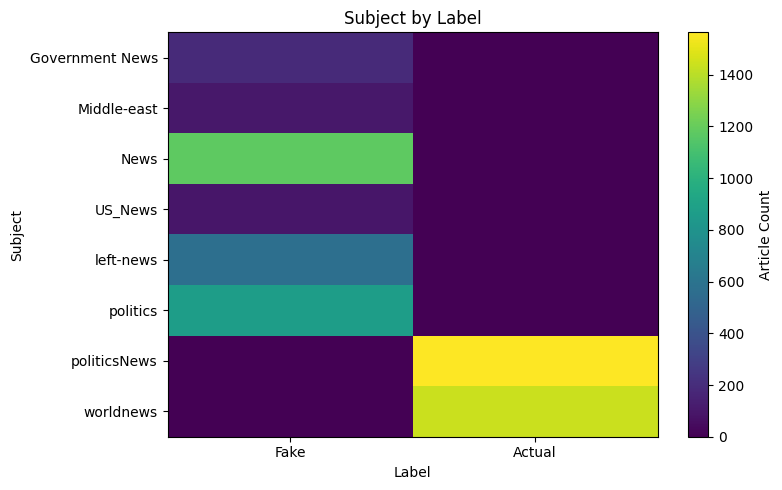

Does every subject map to only one label? True


In [15]:
subject_label_table = pd.crosstab(df_en["subject"], df_en["label"])
subject_label_table.columns = [LABEL_NAMES.get(c, str(c)) for c in subject_label_table.columns]
display(subject_label_table)

plt.figure(figsize=(8, 5))
image = plt.imshow(subject_label_table.values, aspect="auto")
plt.colorbar(image, label="Article Count")
plt.xticks(
    range(len(subject_label_table.columns)),
    subject_label_table.columns
)
plt.yticks(
    range(len(subject_label_table.index)),
    subject_label_table.index
)
plt.title("Subject by Label")
plt.xlabel("Label")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

single_label_subjects = (
    pd.crosstab(df_en["subject"], df_en["label"]).astype(bool).sum(axis=1) == 1
).all()

print("Does every subject map to only one label?", single_label_subjects)
# print("Decision: Exclude subject from model training.")

La variable `Subject` muestra una asociación perfecta con la target en el conjunto de datos en inglés. Esto constituye un artefacto grave del conjunto de datos y una posible fuente de leakage. Por lo tanto, el Subject no debería usarse como característica predictiva. 

In [16]:
# Reuters is a source marker and a strong label shortcut in this dataset.
reuters_check = pd.crosstab(
    df_en["label"],
    df_en["text"].astype(str).str.contains("Reuters", case=False, regex=False),
    normalize="index",
).rename(index=LABEL_NAMES, columns={False: "No Reuters", True: "Contains Reuters"})

display((reuters_check * 100).round(2).astype(str) + "%")

print("Decision: Revisar la palabra Reuters antes del entrenamiento.")
print("Razón: el modelo debería aprender patrones del lenguaje, no el marcador del editor.")

text,No Reuters,Contains Reuters
label,,
Fake,98.2%,1.8%
Actual,0.4%,99.6%


Decision: Revisar la palabra Reuters antes del entrenamiento.
Razón: el modelo debería aprender patrones del lenguaje, no el marcador del editor.


Se detecta una asociación casi perfecta entre el marcador Reuters y la clase Actual, lo que evidencia un fuerte sesgo de fuente en el dataset inglés. Debe investigarse si existen otros marcadores estilísticos o de procedencia antes de definir el preprocessing.

### Temporal distribution

In [17]:
eda_dates = df_en[["date", "label"]].copy()

eda_dates["date_parsed"] = pd.to_datetime(
    eda_dates["date"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
)

print(
    "Unparsed dates:",
    eda_dates["date_parsed"].isna().sum()
)

date_range = (
    eda_dates.groupby("label")["date_parsed"]
    .agg(["min", "max"])
)

date_range.index = date_range.index.map(LABEL_NAMES)

display(date_range)

Unparsed dates: 2


,min,max
label,,
Fake,2015-04-06,2018-02-19
Actual,2016-01-13,2017-12-30


In [18]:
unparsed_dates = eda_dates.loc[
    eda_dates["date_parsed"].isna(),
    ["date", "label"]
]

display(unparsed_dates)

,date,label
3843,MSNBC HOST Rudely Assumes Steel Worker Would N...,0
4910,https://fedup.wpengine.com/wp-content/uploads/...,0


In [19]:
eda_dates["year"] = eda_dates["date_parsed"].dt.year

year_label = pd.crosstab(
    eda_dates["year"],
    eda_dates["label"]
)

year_label.columns = [
    LABEL_NAMES.get(c, str(c))
    for c in year_label.columns
]

display(year_label)

,Fake,Actual
year,,
2015.0,319,0
2016.0,1494,636
2017.0,1180,2364
2018.0,5,0


In [20]:
year_label_pct = pd.crosstab(
    eda_dates["year"],
    eda_dates["label"],
    normalize="columns"
) * 100

year_label_pct.columns = [
    LABEL_NAMES.get(c, str(c))
    for c in year_label_pct.columns
]

display(year_label_pct.round(2))

,Fake,Actual
year,,
2015.0,10.64,0.0
2016.0,49.83,21.2
2017.0,39.36,78.8
2018.0,0.17,0.0


Temporal distribution conclusion: La distribución temporal no es equivalente entre clases. Las noticias Fake incluyen registros de 2015 y 2018, mientras que las noticias Actual se concentran exclusivamente en 2016–2017. Además, el 78,8% de las noticias Actual corresponde a 2017, frente al 39,36% de Fake, mientras que 2016 concentra el 49,83% de Fake frente al 21,2% de Actual. Por tanto, existe un sesgo temporal adicional en la construcción del corpus. date no se utilizará como predictor y las métricas del modelo deberán interpretarse teniendo en cuenta esta diferencia temporal.

### Explore article lenght

In [21]:
eda_df = df_en.copy()
eda_df["combined_raw"] = (
    eda_df["title"].fillna("").astype(str).str.strip()
    + ". "
    + eda_df["text"].fillna("").astype(str).str.strip()
).str.strip()

eda_df["word_count"] = eda_df["combined_raw"].str.split().str.len()
eda_df["char_count"] = eda_df["combined_raw"].str.len()

length_summary = eda_df.groupby("label")[["word_count", "char_count"]].agg(
    ["mean", "median", "min", "max"]
)
length_summary.index = length_summary.index.map(LABEL_NAMES)
display(length_summary.round(2))

print("\nOverall word-count percentiles:")
display(
    eda_df["word_count"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
    .to_frame()
)

word_count                  char_count                    
             mean median min   max       mean  median  min    max
label                                                            
Fake       438.70  376.0   2  8148    2644.11  2241.5   47  51893
Actual     394.07  366.0  37  1955    2437.19  2256.5  251  12470


Overall word-count percentiles:


,word_count
count,6000.00
mean,416.38
std,357.00
min,2.00
50%,371.50
75%,522.00
90%,755.00
95%,917.00
99%,1542.08
max,8148.00


Las distribuciones centrales de longitud son relativamente similares entre clases, aunque la clase fake presenta algunos artículos extremadamente largos que incrementan la media.

In [22]:
eda_df.nlargest(10, "word_count")[
    ["label", "title", "word_count"]
]

,label,title,word_count
5775,0,MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Pro...,8148
5169,0,The Las Vegas Mass Shooting – More to the Stor...,7942
41,0,What is The Deep State?,6258
1008,0,AN AMERICAN TRAGEDY: Who Really Killed JonBené...,5420
3596,0,Activists or Terrorists? How Media Controls an...,4270
4668,0,Here You Go: Every Bat Sh*t Crazy Thing That ...,3927
4284,0,"ANARCHY BY DESIGN: ‘Anti-Trump’ Flash Mobs, Ho...",3810
5685,0,BIGGER THAN SNOWDEN: Wikileaks ‘Vault 7’ Class...,3789
1430,0,SCARS & STRIFE: ‘The Purge Election Year’ Agit...,3557
3366,0,Coke Zero: What Went Wrong With The Marco Rubi...,3511


In [23]:
percentiles_by_class = (
    eda_df
    .groupby("label")["word_count"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .unstack()
)

percentiles_by_class.index = (
    percentiles_by_class.index.map(LABEL_NAMES)
)

percentiles_by_class.columns = [
    "P50",
    "P75",
    "P90",
    "P95",
    "P99"
]

display(percentiles_by_class.round(2))

,P50,P75,P90,P95,P99
label,,,,,
Fake,376.0,517.0,714.2,918.25,1881.46
Actual,366.0,529.0,781.0,915.10,1153.17


Para visualizar la distribución principal sin que los valores extremos oculten su forma, el gráfico se limita al percentil 99. Los outliers permanecen en el dataset y se han analizado separadamente.

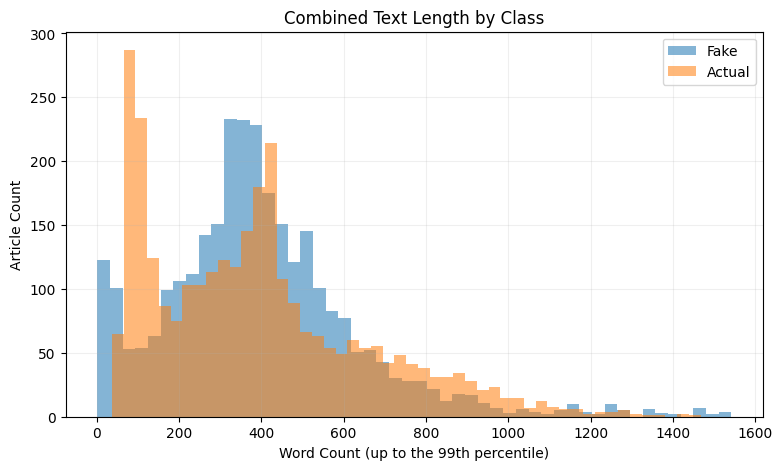

In [24]:
plot_limit = int(
    eda_df["word_count"].quantile(0.99)
)

plt.figure(figsize=(9, 5))

for label, name in LABEL_NAMES.items():

    values = eda_df.loc[
        eda_df["label"] == label,
        "word_count"
    ]

    # Solo para visualización:
    # mostramos el 99% central sin modificar los datos
    values_plot = values[
        values <= plot_limit
    ]

    plt.hist(
        values_plot,
        bins=50,
        alpha=0.55,
        label=name
    )

plt.title("Combined Text Length by Class")
plt.xlabel("Word Count (up to the 99th percentile)")
plt.ylabel("Article Count")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Frequent terms before preprocessing

¿Qué palabras dominan cuantitativamente el contenido de cada clase?

In [25]:
def top_terms_for_class(texts, top_n=20):
    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 1),
        min_df=2,
    )
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.asarray(vectorizer.get_feature_names_out())
    order = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"term": terms[order], "count": counts[order]})

top_fake = top_terms_for_class(
    eda_df.loc[eda_df["label"] == 0, "combined_raw"]
)
top_actual = top_terms_for_class(
    eda_df.loc[eda_df["label"] == 1, "combined_raw"]
)

print("Top terms in fake articles:")
display(top_fake)

print("Top terms in actual articles:")
display(top_actual)

Top terms in fake articles:


,term,count
0,trump,11219
1,said,4376
2,president,3834
3,people,3386
4,just,2834
5,clinton,2613
6,obama,2485
7,like,2393
8,donald,2368
9,video,2147


Top terms in actual articles:


,term,count
0,said,14121
1,trump,8732
2,president,4232
3,reuters,4032
4,state,3117
5,government,2705
6,house,2528
7,new,2470
8,states,2355
9,united,2286


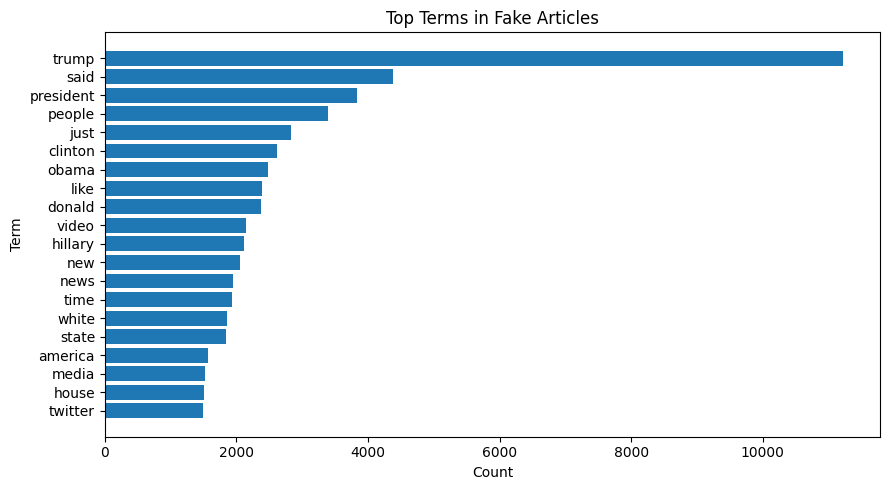

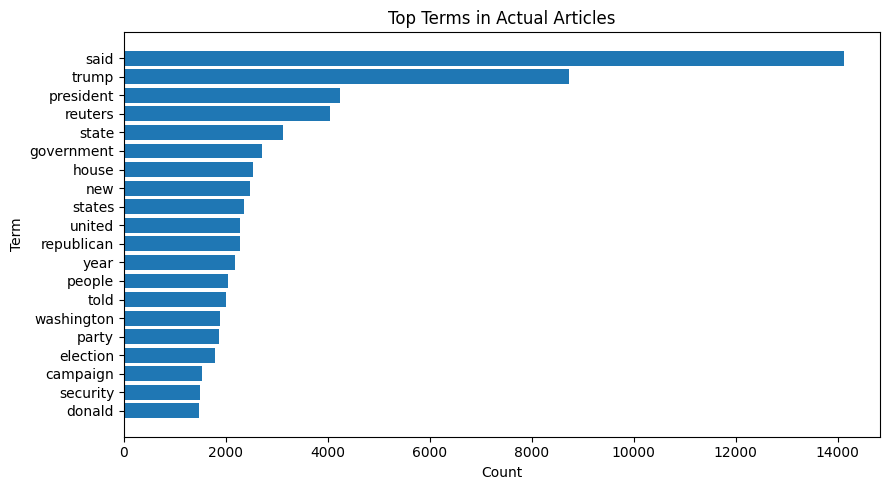

In [26]:
plt.figure(figsize=(9, 5))
plt.barh(top_fake["term"][::-1], top_fake["count"][::-1])
plt.title("Top Terms in Fake Articles")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.barh(top_actual["term"][::-1], top_actual["count"][::-1])
plt.title("Top Terms in Actual Articles")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

Frecuencias absolutas: el vocabulario más frecuente en ambas clases está fuertemente relacionado con la política estadounidense, con términos como trump, president, state o government. Esto evidencia el carácter temático específico del corpus y limita la generalización de los resultados a otros dominios.

### Document Frecuency

¿Qué palabras aparecen de manera sistemáticamente diferente entre las noticias Fake y Actual?

In [27]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2,
    binary=True
)

X_terms = vectorizer.fit_transform(
    eda_df["combined_raw"]
)

terms = np.asarray(
    vectorizer.get_feature_names_out()
)

fake_mask = (
    eda_df["label"].values == 0
)

actual_mask = (
    eda_df["label"].values == 1
)

fake_doc_pct = (
    np.asarray(
        X_terms[fake_mask].mean(axis=0)
    )
    .ravel()
    * 100
)

actual_doc_pct = (
    np.asarray(
        X_terms[actual_mask].mean(axis=0)
    )
    .ravel()
    * 100
)

term_comparison = pd.DataFrame({
    "term": terms,
    "fake_doc_pct": fake_doc_pct,
    "actual_doc_pct": actual_doc_pct
})

term_comparison["difference"] = (
    term_comparison["actual_doc_pct"]
    - term_comparison["fake_doc_pct"]
)

In [28]:
top_actual_terms = (
    term_comparison
    .sort_values(
        "difference",
        ascending=False
    )
    .head(20)
)

display(top_actual_terms.round(2))

,term,fake_doc_pct,actual_doc_pct,difference
3845,reuters,1.70,99.60,97.90
3948,said,55.43,93.63,38.20
4872,washington,13.87,42.17,28.30
2019,government,19.27,39.83,20.57
2887,minister,2.87,23.27,20.40
4583,told,24.83,43.93,19.10
4897,wednesday,7.70,25.93,18.23
4669,tuesday,8.33,26.10,17.77
4561,thursday,7.53,24.90,17.37
4281,state,24.67,41.30,16.63


In [29]:
top_fake_terms = (
    term_comparison
    .sort_values(
        "difference",
        ascending=True
    )
    .head(20)
)

display(top_fake_terms.round(2))

,term,fake_doc_pct,actual_doc_pct,difference
4797,video,43.93,3.27,-40.67
2262,image,38.77,1.30,-37.47
2513,just,51.03,16.90,-34.13
1792,featured,34.40,0.37,-34.03
2675,like,43.87,15.93,-27.93
4875,watch,26.23,2.27,-23.97
936,com,21.67,0.93,-20.73
305,america,28.30,7.90,-20.40
2556,know,27.90,9.07,-18.83
1986,getty,17.30,0.00,-17.30


Frecuencia documental: al comparar el porcentaje de documentos de cada clase que contienen cada término aparecen diferencias mucho más marcadas. Reuters, said o washington, goverment tienen una presencia considerablemente superior en noticias Actual, mientras que términos como video, image, featured o watch aparecen con mucha mayor frecuencia documental en Fake. Estas asociaciones sugieren que el corpus contiene patrones de fuente, formato y estilo que pueden actuar como shortcuts para el clasificador.

### Conclusiones EDA — Inglés (6000 filas)

**Balance de clases:** el dataset está perfectamente balanceado, con un 50% de noticias Fake y un 50% de noticias Actual. Por tanto, no se justifica inicialmente ningún tratamiento de desequilibrio de clases.

**Calidad de datos:** no existen valores NaN, pero se identifican 66 cuerpos de artículo vacíos. Todos pertenecen a la clase Fake, representando el 2,2% de dicha clase, mientras que no existen cuerpos vacíos entre las noticias Actual. Dado que no contienen el cuerpo periodístico que se pretende clasificar y su ausencia está asociada al target, se eliminarán durante el preprocessing.

**Duplicados:** el conteo inicial detecta 170 ocurrencias duplicadas en `text`, pero esta cifra está inflada por los cuerpos vacíos. Excluyendo estos casos se identifican 106 ocurrencias duplicadas de textos con contenido. No existen conflictos de label entre los registros repetidos. Los duplicados deberán resolverse antes del train/test split para evitar que una misma noticia aparezca en conjuntos diferentes.

**Sesgo de metadata y procedencia:** `subject` presenta una asociación perfecta con el target: todas sus categorías pertenecen exclusivamente a Fake o Actual. Por tanto, `subject` no se utilizará como predictor. Además, el término `Reuters` aparece en el 99,6% de las noticias Actual y aproximadamente en el 1,8% de las Fake, constituyendo un fuerte shortcut de procedencia.

**Sesgo temporal:** las clases tampoco presentan la misma distribución temporal. Las noticias Actual se concentran en 2016–2017 y especialmente en 2017, mientras que Fake presenta una proporción considerablemente mayor de noticias de 2016 y contiene además registros de 2015 y 2018. La variable `date` no se utilizará como predictor y esta diferencia deberá considerarse al interpretar la capacidad de generalización del modelo.

**Longitud:** las distribuciones centrales son similares: las medianas son 376 palabras para Fake y 366 para Actual. Sin embargo, la clase Fake presenta una cola extrema considerablemente mayor; en P99 alcanza aproximadamente 1881 palabras frente a 1153 en Actual. Los artículos extremadamente largos no se eliminarán automáticamente y su tratamiento dependerá del modelo utilizado posteriormente.

**Patrones léxicos:** el análisis de document frequency muestra fuertes diferencias entre clases que van más allá de `Reuters`. Términos como `said`, `washington`, `government`, `minister` y `told` aparecen considerablemente más en noticias Actual, mientras que `video`, `image`, `featured` y `watch` son mucho más frecuentes en documentos Fake. Estas diferencias sugieren la presencia de señales de fuente, formato y estilo editorial que un clasificador podría explotar como shortcuts.

**Dominio:** el vocabulario está fuertemente centrado en política estadounidense y entidades como Trump, Clinton u Obama. Por tanto, el corpus representa un dominio temático y temporal limitado y no debe asumirse que el rendimiento obtenido generaliza a fake news de cualquier temática, periodo o procedencia.

**Construcción del texto:** el titular prácticamente nunca aparece repetido al comienzo del cuerpo, por lo que `title` y `text` pueden concatenarse para construir la entrada textual del clasificador sin introducir una duplicación sistemática del titular.

**Conclusión general:** el dataset permite construir un baseline de clasificación textual, pero presenta importantes artefactos de construcción relacionados con temática, fuente, estilo y temporalidad. En consecuencia, un rendimiento elevado del clasificador no podrá interpretarse directamente como capacidad de fact-checking o detección de veracidad. El modelo se utilizará como baseline y señal auxiliar dentro del sistema de verificación basado en evidencia.